# 13 — Inflation as a child of oil, unemployment and expectations

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mamadouyamar/CVineMarketGen/blob/main/examples/13_inflation.ipynb)

Real returns are measured against inflation, and inflation has causes: the
price of oil, the slack of the labour market and what people expect. This
notebook gives U.S. CPI inflation the structural equation of notebook 11, in
its linear form on the monthly rate with three lags: a Phillips-curve reading
with oil pass-through, an unemployment slope and a weight on expectations.
Headline and core inflation are two children of the same parents; the parents
are a block, SPY comes along as the asset. The paths give monthly and
year-on-year inflation, price levels, the response to an oil shock, and the
real return of the asset. Needs `statsmodels`.

Runtime: about 5 minutes.

## Import

In [1]:
import os, sys, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)

ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "examples" else os.getcwd()
sys.path.insert(0, ROOT)                 # run from a local clone, from examples/ or the root
try:
    import cvinemarketgen                # local clone or already installed
except ImportError:                      # e.g. on Google Colab
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "git+https://github.com/mamadouyamar/CVineMarketGen.git[garch,blocks]"], check=True)
    import cvinemarketgen
print("cvinemarketgen", cvinemarketgen.__version__)

for pkg in ("arch", "statsmodels"):
    try:
        __import__(pkg)
    except ImportError:
        import subprocess; subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)
from cvinemarketgen import load_fred_monthly, load_etf_monthly, Targets, CVineMarket, Structural, Paths, iid_tests, price_level, deflate, yoy

cvinemarketgen 0.3.0


## Load and build the series

FRED monthly: the seasonally adjusted headline and core CPI, WTI crude,
the unemployment rate and the Michigan survey's one-year expected inflation,
since October 1993 to match SPY. With $P_t$ the headline index and $P^c_t$ the
core index, inflation is the monthly log change, annualized, in percent,

$$
\pi_t = 1200\, (\log P_t - \log P_{t-1}), \qquad \pi^c_t = 1200\, (\log P^c_t - \log P^c_{t-1});
$$

oil enters through its monthly percent change $\Delta o_t = 100\,(\log O_t - \log O_{t-1})$,
$O_t$ the WTI price; the unemployment rate $u_t$ and expected inflation $e_t$
enter in levels, in percent; SPY's monthly return is $r_t = P^{SPY}_t / P^{SPY}_{t-1} - 1$.
The frames are joined on their common months and the first row, lost to the
differences, dropped. `describe` gives the sample moments: the annualized
monthly rate is a noisy series, with a standard deviation above 3 percent
around a mean near 2.5.

In [2]:
raw = load_fred_monthly(["CPIAUCSL", "CPILFESL", "UNRATE", "DCOILWTICO", "MICH"], start="1993-09", cache=os.path.join(ROOT, "data", "fred_cache.csv"))
spy = load_etf_monthly(["SPY"], start="1993-10", cache=os.path.join(ROOT, "data", "etf_cache_spy.csv"))
data = pd.DataFrame({"pi": 1200 * np.log(raw["CPIAUCSL"]).diff(), "core": 1200 * np.log(raw["CPILFESL"]).diff(),
                     "d_log_oil": 100 * np.log(raw["DCOILWTICO"]).diff(), "unrate": raw["UNRATE"], "mich": raw["MICH"]}).join(spy, how="inner").dropna()
parents = ["d_log_oil", "unrate", "mich"]
print(data.shape[0], "months,", data.index.min(), "to", data.index.max())
data.describe().round(2)

FRED series downloaded: 394 months, 1993-09 to 2026-07, cached to /Users/mamadouthioub/Desktop/CopulaGenerator/CVineMarketGen/data/fred_cache.csv
ETF returns read from cache /Users/mamadouthioub/Desktop/CopulaGenerator/CVineMarketGen/data/etf_cache_spy.csv: 396 months, 1993-10 to 2026-09
393 months, 1993-10 to 2026-07


,pi,core,d_log_oil,unrate,mich,SPY
count,393.00,393.00,393.00,393.00,393.00,393.00
mean,2.54,2.41,0.39,5.53,3.12,0.01
std,3.34,1.53,9.75,1.78,0.76,0.04
min,-21.44,-5.89,-56.82,3.40,0.40,-0.17
25%,0.88,1.54,-5.05,4.30,2.70,-0.02
50%,2.53,2.31,1.39,5.00,3.00,0.01
75%,3.93,2.96,5.69,6.10,3.30,0.04
max,16.41,9.69,54.59,14.80,6.60,0.13


The two inflation rates and the survey expectations $e_t$ on the left, in
percent; the unemployment rate $u_t$ and the oil price $O_t = \exp(\log O_t)$
on the right. The oil price is shown in dollars although the equation uses its
monthly log change.

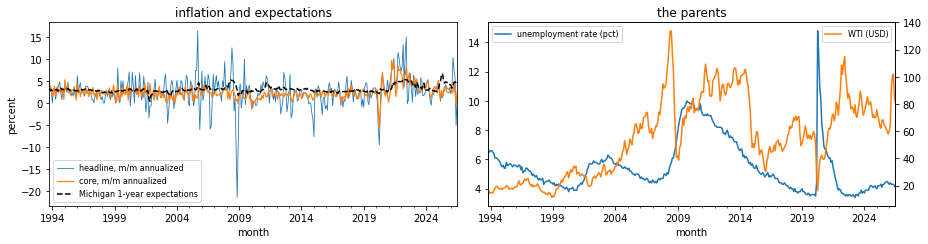

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
data["pi"].plot(ax=axes[0], lw=0.8, label="headline, m/m annualized"); data["core"].plot(ax=axes[0], lw=1.2, label="core, m/m annualized"); data["mich"].plot(ax=axes[0], color="black", ls="--", label="Michigan 1-year expectations")
axes[0].set_ylabel("percent"); axes[0].legend(fontsize=8); axes[0].set_title("inflation and expectations")
data["unrate"].plot(ax=axes[1], label="unemployment rate (pct)"); ax2 = axes[1].twinx(); np.exp(np.log(raw["DCOILWTICO"]).loc[data.index]).plot(ax=ax2, color="tab:orange", label="WTI (USD)")
axes[1].legend(loc="upper left", fontsize=8); ax2.legend(loc="upper right", fontsize=8); axes[1].set_title("the parents"); plt.tight_layout(); plt.show()

## The inflation equation

`Structural` in its linear form fits, by least squares,

$$
\pi_t = c + \gamma_o\, \Delta o_t + \gamma_u\, u_t + \gamma_e\, e_t + \sum_{i=1}^{3} \phi_i\, \pi_{t-i} + \sigma\, \varepsilon_t,
$$

with parents $\mathbf{z}_t = (\Delta o_t, u_t, e_t)'$: the pass-through of this
month's oil move ($\gamma_o$), the slope on unemployment ($\gamma_u$), the weight
of expectations ($\gamma_e$), and three lags of inflation itself. Stacking the
$n$ usable months, $\boldsymbol{\pi} = \mathbf{X} \boldsymbol{\beta} + \mathbf{e}$
with $\mathbf{X}$ the $n \times 7$ design matrix (constant, the three parents,
the three lags), the estimates and their classical standard errors are

$$
\hat{\boldsymbol{\beta}} = (\mathbf{X}'\mathbf{X})^{-1} \mathbf{X}' \boldsymbol{\pi}, \qquad
\hat\sigma^2 = \frac{\mathbf{e}'\mathbf{e}}{n - 7}, \qquad
t_j = \frac{\hat\beta_j}{\hat\sigma \sqrt{[(\mathbf{X}'\mathbf{X})^{-1}]_{jj}}},
$$

and $R^2 = 1 - \mathbf{e}'\mathbf{e} / \sum_t (\pi_t - \bar\pi)^2$. Two readings
of the coefficients: a 10 percent rise of oil within the month adds
$10\,\gamma_o$ points to the annualized monthly rate on impact and
$10\,\gamma_o / (1 - \sum_i \phi_i)$ in the long run if the parents held;
$\sum_i \phi_i$ is the persistence. $\varepsilon_t$ is the child's residual
layer. The table gives $\hat\beta_j$ and $t_j$ for headline.

In [4]:
m = Structural(parents, form="linear", lags=3).fit(data["pi"], data[parents])
print(m.name, "| R2", round(m.r2, 3), "| sigma", round(m.sigma, 3), "| n", m.n_obs)
coef = pd.Series({"const": m.const, "d_log_oil": m.gamma["d_log_oil"], "unrate": m.gamma["unrate"], "mich": m.gamma["mich"], "pi_l1": m.phi[0], "pi_l2": m.phi[1], "pi_l3": m.phi[2]})
tst = pd.Series({"const": m.tstat["const"], "d_log_oil": m.tstat["d_log_oil"], "unrate": m.tstat["unrate"], "mich": m.tstat["mich"], "pi_l1": m.tstat["s_l1"], "pi_l2": m.tstat["s_l2"], "pi_l3": m.tstat["s_l3"]})
pd.DataFrame({"coefficient": coef, "t": tst}).round(3)

Linear(pi | d_log_oil, unrate, mich) | R2 0.518 | sigma 2.346 | n 390


,coefficient,t
const,0.263,0.388
d_log_oil,0.168,13.657
unrate,-0.190,-2.723
mich,0.842,4.489
pi_l1,0.410,9.377
pi_l2,-0.200,-4.308
pi_l3,0.034,0.779


The same equation on core inflation $\pi^c_t$, with the same three parents and
three lags, gives the second child. The table sets the headline coefficients
next to core's with core's $t$-statistics; the ratio of the two oil
coefficients is the share of the pass-through that reaches the index net of
food and energy, and core's larger $\phi_1$ is its greater inertia.

In [5]:
mc = Structural(parents, form="linear", lags=3).fit(data["core"], data[parents])
print(mc.name, "| R2", round(mc.r2, 3), "| sigma", round(mc.sigma, 3))
pd.DataFrame({"headline": coef, "core": pd.Series({"const": mc.const, "d_log_oil": mc.gamma["d_log_oil"], "unrate": mc.gamma["unrate"], "mich": mc.gamma["mich"], "pi_l1": mc.phi[0], "pi_l2": mc.phi[1], "pi_l3": mc.phi[2]}),
              "t (core)": pd.Series({"const": mc.tstat["const"], "d_log_oil": mc.tstat["d_log_oil"], "unrate": mc.tstat["unrate"], "mich": mc.tstat["mich"], "pi_l1": mc.tstat["s_l1"], "pi_l2": mc.tstat["s_l2"], "pi_l3": mc.tstat["s_l3"]})}).round(3)

Linear(core | d_log_oil, unrate, mich) | R2 0.383 | sigma 1.209


,headline,core,t (core)
const,0.263,1.104,3.041
d_log_oil,0.168,0.027,4.274
unrate,-0.190,-0.158,-4.071
mich,0.842,0.406,4.356
pi_l1,0.410,0.380,7.548
pi_l2,-0.200,0.080,1.484
pi_l3,0.034,-0.089,-1.776


Read the headline equation: a 10 percent rise in oil within the month adds
about 1.8 points to the annualized monthly rate that month (the pass-through
to gasoline), a one-point higher unemployment rate lowers it, expectations
enter with a coefficient near one, and the lags add persistence. Core has a
much smaller oil coefficient and a larger own persistence: the oil shock
reaches core slowly and through expectations.

## The children's residual layer

The standardized innovation of each equation, $\varepsilon_t = e_t / \hat\sigma$,
tested for independence over time with $m = 20$ lags: the Ljung-Box statistic
$Q(m) = n(n+2) \sum_{j=1}^{m} \hat\rho_j^2 / (n - j) \sim \chi^2_m$ on
$\varepsilon_t$ (`lb_z`) and on $\varepsilon_t^2$ (`lb_z2`), and the ARCH-LM
statistic $n R^2$ of the regression of $\varepsilon_t^2$ on its $m$ lags
(`arch_lm`); the table gives $p$-values, below 0.05 rejecting. `describe` gives
the sample moments of the two innovations: mean zero by construction, standard
deviation slightly below one because $\hat\sigma$ divides by $n - 7$, and the
range in standard deviations.

In [6]:
z = pd.DataFrame({"pi": m.filter(), "core": mc.filter()})
print(pd.DataFrame({c: iid_tests(z[c].values) for c in z.columns}).round(3))
z.describe().round(3)

            pi   core
lb_z     0.197  0.005
lb_z2    0.000  0.000
arch_lm  0.005  0.000


,pi,core
count,390.000,390.000
mean,0.000,0.000
std,0.992,0.992
min,-5.732,-2.797
25%,-0.547,-0.582
50%,0.043,-0.025
75%,0.572,0.526
max,4.985,5.750


Correlations of the two innovations with each other, with the parents'
contemporaneous values and with SPY's return. By the normal equations of least
squares, $\mathbf{X}' \mathbf{e} = \mathbf{0}$, each innovation is exactly
uncorrelated with its regressors, so the columns for $\Delta o_t$, $u_t$ and
$e_t$ read zero: the link between inflation and its parents is in
$\boldsymbol{\gamma}$, not in the copula. The two children share their parents,
so the correlation between their innovations is the co-movement the parents do
not explain: it is what the vine carries, together with the correlation with
SPY.

In [7]:
pd.concat([z, data[parents].loc[z.index], data["SPY"].loc[z.index]], axis=1).corr().round(2).loc[["pi", "core"]]

,pi,core,d_log_oil,unrate,mich,SPY
pi,1.00,0.25,0.0,-0.0,0.0,0.01
core,0.25,1.00,0.0,0.0,-0.0,0.02


## The market: parents as a block, two children, SPY alongside

The parents are a block, $\mathbf{z}_t = (\Delta o_t, u_t, e_t)'$, filtered by the
vector error-correction model

$$
\Delta \mathbf{z}_t = \mathbf{c} + \boldsymbol{\alpha}\boldsymbol{\beta}' \mathbf{z}_{t-1} + \sum_{i=1}^{q} \boldsymbol{\Gamma}_i \Delta \mathbf{z}_{t-i} + \boldsymbol{\eta}_t,
$$

with the rank $r$ of $\boldsymbol{\alpha}\boldsymbol{\beta}'$ left to the
Johansen trace test: for the hypothesis of rank at most $r$,
$\mathrm{LR}(r) = -T \sum_{i=r+1}^{3} \ln(1 - \hat\lambda_i)$ with $\hat\lambda_i$
the eigenvalues of the reduced-rank regression (constant included,
`det_order=0`), compared with the 5 percent critical value; the rank is the
smallest $r$ not rejected. The change of oil is stationary and so, at the 5
percent level, are the unemployment rate and expectations, so the test rejects
every rank below three: $\boldsymbol{\Pi}$ has full rank and the block is a
stationary VAR in levels, which the VECM parametrisation represents exactly.
The two children are `'linear(d_log_oil, unrate, mich; lags=3)'`; SPY keeps its
AR(1)-GARCH. `order` shows the block fitted and simulated before the children.

One intervention. The unemployment rate rose from 4.4 to 14.7 percent in April
2020, a 14-sigma innovation of the block, and fell back over the following
months. No four-moment marginal can carry one such observation in 393 (the
sample kurtosis is 226), so the four pandemic months are excluded from the
residual layer on which the marginals and the vine are fitted: `exclude=[...]`.
The filters are still estimated on the whole history and the paths start from
the last observed state.

In [8]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen
rows = {}
for q in (1, 2):
    j = coint_johansen(data[parents].values, det_order=0, k_ar_diff=q)
    rej = j.lr1 > j.cvt[:, 1]; rank = int(np.argmin(rej)) if not rej.all() else 3
    rows[f"q = {q}"] = {"trace, r = 0": j.lr1[0], "crit 5%": j.cvt[0, 1], "trace, r <= 1": j.lr1[1], "crit 5% ": j.cvt[1, 1], "trace, r <= 2": j.lr1[2], "crit 5%  ": j.cvt[2, 1], "rank": rank}
pd.DataFrame(rows).T.round(2)

,"trace, r = 0",crit 5%,"trace, r <= 1",crit 5%,"trace, r <= 2",crit 5%,rank
q = 1,193.96,29.8,34.37,15.49,8.72,3.84,3.0
q = 2,170.29,29.8,27.29,15.49,8.23,3.84,3.0


The residual layer has six columns: the block's standardized innovations
$\varepsilon_{k,t} = \hat\eta_{k,t} / \hat\sigma_k$ (each divided by its own
standard deviation only), the two children's innovations $\varepsilon^\pi_t$ and
$\varepsilon^c_t$, and SPY's GARCH residual. With `exclude`, the targets of the
generator are the sample moments and correlations of
$\{\boldsymbol{\varepsilon}_t : t \notin \mathcal{E}\}$, $\mathcal{E}$ the four
months listed, and the vine is fitted on the same rows; the filters themselves
use every month, so $\hat\sigma_k$ is the full-sample scale and the excluded
months' innovations are simply not in the fit of the marginals and the copula.
Kurtosis is floored at $3.1 + 2\gamma_1^2$ where needed. `dynamics_report`
lists the models, parameter counts and BIC; the block's three rows share one
likelihood.

In [9]:
t = Targets.from_history(data)
spec = "linear(d_log_oil, unrate, mich; lags=3)"
exclude = ["2020-03", "2020-04", "2020-05", "2020-06"]        # the pandemic months, left out of the residual layer's fit
t0 = time.time()
cv = CVineMarket(t, central="SPY", families="auto",
                 dynamics={("d_log_oil", "unrate", "mich"): "vecm", "pi": spec, "core": spec, "SPY": "ar1-garch"}, exclude=exclude).fit()
print(f"fit: {time.time() - t0:.0f} s | order:", cv.dynamics.order)
cv.dynamics_report

fit: 492 s | order: [('d_log_oil', 'unrate', 'mich'), 'SPY', 'pi', 'core']


,model,n_params,loglik,bic
pi,"Linear(pi | d_log_oil, unrate, mich)",8,-882.424771,1812.578715
core,"Linear(core | d_log_oil, unrate, mich)",8,-623.744544,1295.218262
d_log_oil,"VECM(r=3, q=1)",24,-1815.379685,3774.008352
unrate,"VECM(r=3, q=1)",24,-1815.379685,3774.008352
mich,"VECM(r=3, q=1)",24,-1815.379685,3774.008352
SPY,"AR(1)-GARCH(1,1)",5,704.456706,-1379.057102


The targets and the vine. `fit_targets.moments` gives mean, volatility,
skewness and kurtosis of each residual column on the retained months: the
block's volatilities are below one because $\hat\sigma_k$ was estimated on all
months, the pandemic included, and the unemployment innovation's is the
smallest. `fit_targets.corr` is the correlation matrix the calibration
reproduces. `edges` lists each pair-copula of the C-vine with SPY as the central
node, with family, rotation, or mixture $w C_1 + (1 - w) C_2$, and calibrated
parameters; a Gumbel with parameter $\theta$ has an upper-tail coefficient
$2 - 2^{1/\theta}$, a Clayton a lower-tail coefficient $2^{-1/\theta}$.

In [10]:
print(cv.fit_targets.moments.round(2)); print(cv.fit_targets.corr.round(2)); cv.edges

           mean   vol  skew  kurt
SPY       -0.05  0.99 -0.68  4.02
pi         0.00  0.98 -0.42  7.94
core       0.01  0.98  0.98  7.07
d_log_oil  0.02  0.93 -0.06  3.55
unrate    -0.03  0.47 -0.36  7.00
mich      -0.00  1.00  0.32  9.23
            SPY    pi  core  d_log_oil  unrate  mich
SPY        1.00  0.01  0.03       0.08   -0.02 -0.05
pi         0.01  1.00  0.27       0.04    0.09  0.12
core       0.03  0.27  1.00      -0.06   -0.01 -0.04
d_log_oil  0.08  0.04 -0.06       1.00   -0.16  0.21
unrate    -0.02  0.09 -0.01      -0.16    1.00 -0.02
mich      -0.05  0.12 -0.04       0.21   -0.02  1.00


,tree,edge,selected family,parameters
0,1,"pi , SPY",clayton 180° + clayton 270°,"w=0.95, theta=(0.077, 6.300)"
1,1,"core , SPY",clayton 180° + clayton 270°,"w=0.86, theta=(0.190, 1.556)"
2,1,"d_log_oil , SPY",clayton 0° + clayton 90°,"w=0.94, theta=(0.176, 8.032)"
3,1,"unrate , SPY",clayton 270° + gumbel 0°,"w=0.16, theta=(0.576, 1.045)"
4,1,"mich , SPY",clayton 180° + gumbel 90°,"w=0.78, theta=(0.339, 5.146)"
5,2,"core , pi | SPY",gumbel 0°,theta=1.181
6,2,"d_log_oil , pi | SPY",joe 180°,theta=1.053
7,2,"unrate , pi | SPY",gumbel 180°,theta=1.039
8,2,"mich , pi | SPY",joe 180°,theta=1.121
9,3,"d_log_oil , core | SPY, pi",clayton 270°,theta=0.105


## Paths of inflation

1,000 paths of 24 months from the last observed month. The vine draws the six
residual columns for every path and month; the block gives the parents by its
recursion in levels from the last observed rows; each child is rebuilt from
the parents' simulated values and its own draw,

$$
\pi^{(s)}_t = \hat c + \hat{\boldsymbol{\gamma}}' \mathbf{z}^{(s)}_t + \sum_{i=1}^{3} \hat\phi_i\, \pi^{(s)}_{t-i} + \hat\sigma\, \varepsilon^{(s)}_t,
$$

with the observed rates as lags for $t - i \le 0$. From the monthly rates,
`yoy` gives the year-on-year rate and `price_level` the index from 100 at the
last observation,

$$
\pi^{yoy, (s)}_t = 100 \left[ \exp\Big( \tfrac{1}{1200} \sum_{j=t-11}^{t} \pi^{(s)}_j \Big) - 1 \right], \qquad
P^{(s)}_t = 100 \exp\Big( \tfrac{1}{1200} \sum_{j=1}^{t} \pi^{(s)}_j \Big),
$$

the first eleven year-on-year windows reaching back into the observed months.
The fans show the quantiles across paths by month of the three quantities; the
dotted lines are the last observed monthly and year-on-year rates. The table
gives the 5, 50 and 95 percent quantiles at months 1, 12 and 24.

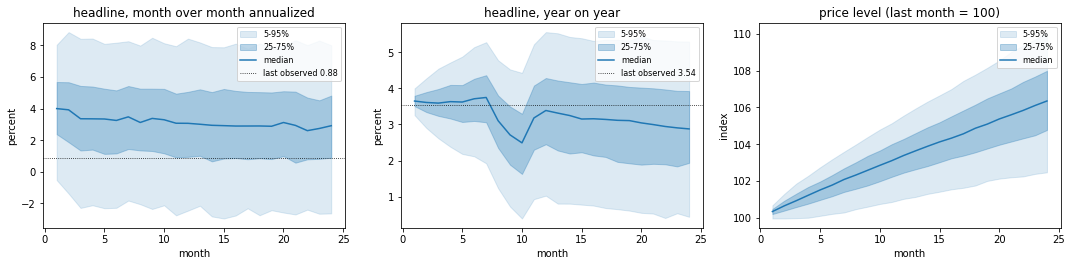

m/m annualized  year on year  price level
quantile month                                           
5%       1               -0.53          3.26        99.96
         12              -2.46          1.03       101.03
         24              -2.64          0.44       102.47
50%      1                4.00          3.65       100.33
         12               3.07          3.39       103.39
         24               2.92          2.88       106.35
95%      1                8.04          4.00       100.67
         12               8.43          5.56       105.56
         24               8.01          5.30       110.10

In [11]:
P = cv.simulate_paths(1000, 24, seed=1)
Y = yoy(P, "pi", data["pi"]); L = price_level(P, "pi")
last_yoy = 100 * (np.exp(data["pi"].iloc[-12:].sum() / 1200) - 1)
def fan(ax, X, last, title, ylabel="percent"):
    q = np.quantile(X, [0.05, 0.25, 0.5, 0.75, 0.95], axis=0); h = X.shape[1]
    ax.fill_between(range(1, h + 1), q[0], q[4], color="tab:blue", alpha=0.15, label="5-95%"); ax.fill_between(range(1, h + 1), q[1], q[3], color="tab:blue", alpha=0.3, label="25-75%")
    ax.plot(range(1, h + 1), q[2], color="tab:blue", label="median")
    if last is not None: ax.axhline(last, color="black", lw=0.8, ls=":", label=f"last observed {last:.2f}")
    ax.set_xlabel("month"); ax.set_ylabel(ylabel); ax.set_title(title); ax.legend(fontsize=8)
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
fan(axes[0], P.array[:, :, P.assets.index("pi")], data["pi"].iloc[-1], "headline, month over month annualized")
fan(axes[1], Y, last_yoy, "headline, year on year")
fan(axes[2], L, None, "price level (last month = 100)", "index"); plt.tight_layout(); plt.show()
pd.DataFrame({"m/m annualized": np.quantile(P.array[:, :, P.assets.index("pi")], [0.05, 0.5, 0.95], axis=0)[:, [0, 11, 23]].ravel(),
              "year on year": np.quantile(Y, [0.05, 0.5, 0.95], axis=0)[:, [0, 11, 23]].ravel(),
              "price level": np.quantile(L, [0.05, 0.5, 0.95], axis=0)[:, [0, 11, 23]].ravel()},
             index=pd.MultiIndex.from_product([["5%", "50%", "95%"], [1, 12, 24]], names=["quantile", "month"])).round(2)

## An oil scenario

A scenario is a change of a parent's residual draw. The oil innovation is
shifted by a drift over the first six months,

$$
\tilde\varepsilon^{o, (s)}_t = \varepsilon^{o, (s)}_t + \delta, \quad t = 1, \dots, 6, \qquad \delta = \frac{50}{6\, \hat\sigma_o},
$$

so that the cumulated shift in the block's units, $6\, \hat\sigma_o\, \delta = 50$,
is a rise of 50 percent in the log of the oil price; every other draw is as in
the baseline, and the same residual matrix `E` (in the column order
`cv.dynamics.columns`, the one `unfilter` expects) is pushed through the models
twice. Headline inflation answers at once through $\gamma_o$ and then through
its lags; core answers less and later; the price level records the cumulative
effect. The table compares the medians across paths, baseline and scenario, of
the oil change, the two monthly rates and the price level at months 1, 3, 6, 12
and 24.

In [12]:
cols = cv.dynamics.columns
E = cv.simulate(1000 * 24, seed=1, accept=False).loc[:, cols].values.reshape(1000, 24, len(cols))
base = cv.dynamics.unfilter(E)
blk = cv.dynamics.models[("d_log_oil", "unrate", "mich")]; sigma_oil = blk.sigma[blk.columns.index("d_log_oil")]
Es = E.copy(); Es[:, :6, cols.index("d_log_oil")] += 50.0 / 6 / sigma_oil        # +50 percent of log oil over six months
shock = cv.dynamics.unfilter(Es)
Pb = Paths(base, cols, layer="mixed"); Ps = Paths(shock, cols, layer="mixed")
med = lambda A, c: np.median(A[:, :, cols.index(c)], axis=0)
tab = pd.DataFrame({"oil change, median (baseline)": med(base, "d_log_oil"), "oil change, median (scenario)": med(shock, "d_log_oil"),
                    "headline, median (baseline)": med(base, "pi"), "headline, median (scenario)": med(shock, "pi"),
                    "core, median (baseline)": med(base, "core"), "core, median (scenario)": med(shock, "core"),
                    "price level, median (baseline)": np.median(price_level(Pb, "pi"), axis=0), "price level, median (scenario)": np.median(price_level(Ps, "pi"), axis=0)},
                   index=range(1, 25)).loc[[1, 3, 6, 12, 24]].round(2)
tab.T

,1,3,6,12,24
"oil change, median (baseline)",-2.45,-0.37,-0.15,-0.88,0.70
"oil change, median (scenario)",5.89,11.20,10.61,-1.54,0.38
"headline, median (baseline)",4.00,3.36,3.25,3.07,2.92
"headline, median (scenario)",5.40,6.32,6.28,3.46,3.09
"core, median (baseline)",2.71,3.25,2.95,2.75,2.56
"core, median (scenario)",2.94,3.89,3.88,3.13,2.76
"price level, median (baseline)",100.33,100.92,101.77,103.39,106.35
"price level, median (scenario)",100.45,101.51,103.13,105.10,108.38


The same comparison on the year-on-year rates, which accumulate the six months
of the shock and carry it until it drops out of the twelve-month window, and
on the price level, whose gap between scenario and baseline is the permanent
effect of a one-time rise in the level of oil on the level of prices.

The year-on-year rate plotted is $\pi^{yoy,(s)}_t$ of the previous cell, computed on the baseline paths and on the scenario paths from the same residual matrix; the price level is $P^{(s)}_t = 100\exp(\sum_{j \le t} \pi^{(s)}_j / 1200)$.

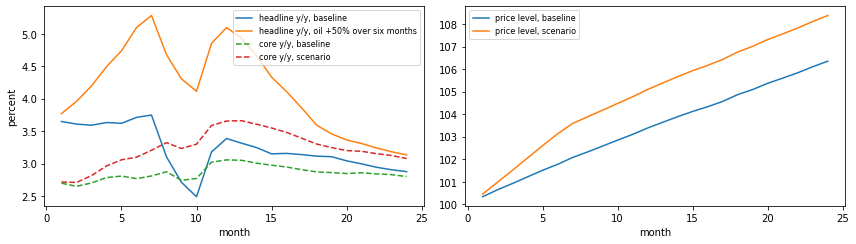

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].plot(range(1, 25), np.median(yoy(Pb, "pi", data["pi"]), axis=0), label="headline y/y, baseline"); axes[0].plot(range(1, 25), np.median(yoy(Ps, "pi", data["pi"]), axis=0), label="headline y/y, oil +50% over six months")
axes[0].plot(range(1, 25), np.median(yoy(Pb, "core", data["core"]), axis=0), ls="--", label="core y/y, baseline"); axes[0].plot(range(1, 25), np.median(yoy(Ps, "core", data["core"]), axis=0), ls="--", label="core y/y, scenario")
axes[0].set_xlabel("month"); axes[0].set_ylabel("percent"); axes[0].legend(fontsize=8)
axes[1].plot(range(1, 25), np.median(price_level(Pb, "pi"), axis=0), label="price level, baseline"); axes[1].plot(range(1, 25), np.median(price_level(Ps, "pi"), axis=0), label="price level, scenario")
axes[1].set_xlabel("month"); axes[1].legend(fontsize=8); plt.tight_layout(); plt.show()

## Real returns

`deflate` turns SPY's simulated nominal returns into real ones month by month
with the simulated headline inflation of the same path,

$$
r^{real, (s)}_t = \frac{1 + r^{(s)}_t}{\exp(\pi^{(s)}_t / 1200)} - 1,
$$

the two being drawn together, so the real return carries their dependence.
The table gives the 5, 50 and 95 percent quantiles across paths of the
cumulative nominal return $\prod_{j \le t} (1 + r^{(s)}_j) - 1$ and of the
cumulative real return at months 12 and 24, in percent.

In [14]:
R = deflate(P, "SPY", "pi")
nom = P.array[:, :, P.assets.index("SPY")]; cum_nom = np.cumprod(1 + nom, axis=1) - 1; cum_real = R.cumulative().array[:, :, 0]
pd.DataFrame({"nominal, month 12": np.quantile(cum_nom[:, 11], [0.05, 0.5, 0.95]), "real, month 12": np.quantile(cum_real[:, 11], [0.05, 0.5, 0.95]),
              "nominal, month 24": np.quantile(cum_nom[:, 23], [0.05, 0.5, 0.95]), "real, month 24": np.quantile(cum_real[:, 23], [0.05, 0.5, 0.95])},
             index=["5%", "50%", "95%"]).mul(100).round(1)

,"nominal, month 12","real, month 12","nominal, month 24","real, month 24"
5%,-14.9,-17.3,-16.1,-20.9
50%,11.7,8.1,23.1,15.9
95%,36.1,31.6,63.8,54.5


## Without the structure: an AR(1) on inflation alone

The alternative filters headline inflation on its own,
$\pi_t = c + \phi\, \pi_{t-1} + \sigma\, \varepsilon_t$, whose paths revert to
the sample mean $c / (1 - \phi)$ and whose residual keeps whatever the parents
explained. The vine is then left to carry the co-movement with oil as a
residual correlation, and the oil scenario has no channel to inflation beyond
the copula. The cell fits the alternative market with the same block, the same
core equation and the same exclusion, simulates the same number of paths, and
compares: the residual tests of the two filters, the year-on-year distribution
at 24 months (median, 5 and 95 percent quantiles, standard deviation across
paths), and the residual correlation between headline's innovation and the oil
innovation, zero by construction under the equation.

In [15]:
cv1 = CVineMarket(t, central="SPY", families="auto",
                  dynamics={("d_log_oil", "unrate", "mich"): "vecm", "pi": "ar1", "core": spec, "SPY": "ar1-garch"}, exclude=exclude).fit()
P1 = cv1.simulate_paths(1000, 24, seed=1); Y1 = yoy(P1, "pi", data["pi"])
za = cv1.dynamics.filter(data)["pi"]
print(pd.DataFrame({"structural": iid_tests(z["pi"].values), "AR(1)": iid_tests(za.values)}).round(3))
pd.DataFrame({"structural": [np.median(Y[:, 23]), np.quantile(Y[:, 23], 0.05), np.quantile(Y[:, 23], 0.95), Y[:, 23].std(), cv.fit_targets.corr.loc["pi", "d_log_oil"]],
              "AR(1) on pi": [np.median(Y1[:, 23]), np.quantile(Y1[:, 23], 0.05), np.quantile(Y1[:, 23], 0.95), Y1[:, 23].std(), cv1.fit_targets.corr.loc["pi", "d_log_oil"]]},
             index=["y/y median, month 24", "y/y 5%, month 24", "y/y 95%, month 24", "y/y sd, month 24", "residual corr(pi, oil innovation)"]).round(3)

         structural  AR(1)
lb_z          0.197    0.0
lb_z2         0.000    0.0
arch_lm       0.005    0.0


,structural,AR(1) on pi
"y/y median, month 24",2.876,2.630
"y/y 5%, month 24",0.440,0.059
"y/y 95%, month 24",5.297,5.040
"y/y sd, month 24",1.495,1.547
"residual corr(pi, oil innovation)",0.035,0.483


## Save

`cv.save` writes the fitted market to JSON: targets, the Johnson SU parameters
of each residual column, the vine's edges, and the dynamics with the block's
last observed state, the children's coefficients and the excluded periods, so
that `load` simulates without refitting; the last line checks this with three
paths of six months. The stored marginals are the Johnson SU quantile functions $F_i^{-1}(u) = \mu_i + \sigma_i\, q_i(\Phi^{-1}(u))$ of the residual columns.

In [16]:
cv.save("inflation_market.json")
CVineMarket.load("inflation_market.json").simulate_paths(3, 6, seed=2)

Paths(n_paths=3, horizon=6, assets=6, returns)

## Where to go next

The price-level paths and the real curve of notebook 12 (TIPS yields through
the same Nelson-Siegel module) price inflation-linked bonds; the GDP notebook
adds the quarterly series to the monthly market.